In [1]:
import glob, os
import numpy as np
import pandas as pd
import matplotlib as mpl
from pathlib import Path
import astropy.units as u
from astropy.table import Table
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from astropy.coordinates import SkyCoord
from matplotlib.colors import LogNorm
from matplotlib.gridspec import GridSpec

# 
from myutils import all_utils as au


In [2]:
# Path plots
path_plots = "paper_plots/proprietary_ocean/"
os.mkdir(path_plots) if not os.path.exists(path_plots) else None


In [3]:

df_header_list=[]
df_phot_list=[]
list_to_read = glob.glob("data/SIMS_KN_OCEAN_250_YDET/*/*PHOT.FITS.gz")
print(f"Found {len(list_to_read)} PHOT.FITS.gz files to read.")
for fphot in list_to_read:
    df_header_tmp, df_phot_tmp = au.read_fits(fphot, drop_separators=True)
    print(f"Reading {fphot} with length {len(df_phot_tmp)}")
    df_header_list.append(df_header_tmp)
    df_phot_list.append(df_phot_tmp)
df_header = pd.concat(df_header_list, ignore_index=True)
# Read all PHOT.FITS.gz files and concatenate them    
df_phot = pd.concat(df_phot_list, ignore_index=True)
print(f"Number of light curves: {len(df_header)}")
print(f"Number of photometric points: {df_phot.groupby('SNID').count()['MJD'].median()} +- {df_phot.groupby('SNID').count()['MJD'].std()}")

Found 40 PHOT.FITS.gz files to read.
Reading data/SIMS_KN_OCEAN_250_YDET/PIP_AMR_KN_OCEAN_LSST_KN_KASEN_NOHOST/PIP_AMR_KN_OCEAN_LSST_KN_5c695_NONIaMODEL00-0004_PHOT.FITS.gz with length 4817
Reading data/SIMS_KN_OCEAN_250_YDET/PIP_AMR_KN_OCEAN_LSST_KN_KASEN_NOHOST/PIP_AMR_KN_OCEAN_LSST_KN_5c695_NONIaMODEL00-0003_PHOT.FITS.gz with length 7218
Reading data/SIMS_KN_OCEAN_250_YDET/PIP_AMR_KN_OCEAN_LSST_KN_KASEN_NOHOST/PIP_AMR_KN_OCEAN_LSST_KN_5c695_NONIaMODEL00-0016_PHOT.FITS.gz with length 4314
Reading data/SIMS_KN_OCEAN_250_YDET/PIP_AMR_KN_OCEAN_LSST_KN_KASEN_NOHOST/PIP_AMR_KN_OCEAN_LSST_KN_5c695_NONIaMODEL00-0011_PHOT.FITS.gz with length 5123
Reading data/SIMS_KN_OCEAN_250_YDET/PIP_AMR_KN_OCEAN_LSST_KN_KASEN_NOHOST/PIP_AMR_KN_OCEAN_LSST_KN_5c695_NONIaMODEL00-0020_PHOT.FITS.gz with length 4516
Reading data/SIMS_KN_OCEAN_250_YDET/PIP_AMR_KN_OCEAN_LSST_KN_KASEN_NOHOST/PIP_AMR_KN_OCEAN_LSST_KN_5c695_NONIaMODEL00-0010_PHOT.FITS.gz with length 4359
Reading data/SIMS_KN_OCEAN_250_YDET/PIP_AMR_K

In [4]:
for snr in [1,2,3]:
    print(f"SNR {snr}")
    dic_snr_3 = au.get_snr_sampling(df_header, df_phot,snr_threshold=snr)
dic_snr_5 = au.get_snr_sampling(df_header, df_phot,snr_threshold=5)

SNR 1

Number of light curves with SIM_GENTYPE = 50 | Kasen: 4226
3885 light curves have 1 detection with SNR > 1 = 91.93% of this type
3420 light curves have 2 detections with SNR > 1 = 80.93% of this type
3217 light curves have 2 detections with SNR > 1 in >1 day = 76.12% of this type

Number of light curves with SIM_GENTYPE = 51 | Bulla: 4261
3909 light curves have 1 detection with SNR > 1 = 91.74% of this type
3473 light curves have 2 detections with SNR > 1 = 81.51% of this type
3236 light curves have 2 detections with SNR > 1 in >1 day = 75.94% of this type
SNR 2

Number of light curves with SIM_GENTYPE = 50 | Kasen: 4226
2395 light curves have 1 detection with SNR > 2 = 56.67% of this type
1401 light curves have 2 detections with SNR > 2 = 33.15% of this type
1261 light curves have 2 detections with SNR > 2 in >1 day = 29.84% of this type

Number of light curves with SIM_GENTYPE = 51 | Bulla: 4261
2463 light curves have 1 detection with SNR > 2 = 57.80% of this type
1447 light c

In [5]:


def get_snr_sampling_table(df_header, df_phot, snr_threshold=3):
    """
    Compute percentages of light curves with detections above a given SNR threshold.
    Returns a DataFrame with SIM_GENTYPE averages and per-model percentages.
    """

    records = []

    for typ in df_header.SIM_GENTYPE.unique():
        # Select matching SNIDs
        sel_snids = df_header[df_header.SIM_GENTYPE == typ].SNID
        total_typ_snids = len(sel_snids)

        # Photometry for this type
        sel = df_phot[df_phot.SNID.isin(sel_snids)]
        typ_str = au.dic_sntype[str(typ)]

        # Light curves with at least 1 detection
        snr_sel = sel[sel['SNR'] > snr_threshold]
        one_det = snr_sel['SNID'].nunique()

        # Light curves with at least 2 detections
        snr_counts = snr_sel.groupby('SNID').size()
        two_det = (snr_counts >= 2).sum()

        # Light curves with 2 detections separated by >1 day
        def has_two_sep_days(group):
            mjds = group['MJD'].sort_values().values
            for i in range(len(mjds)):
                for j in range(i+1, len(mjds)):
                    if abs(mjds[j] - mjds[i]) > 1:
                        return True
            return False

        two_sep_days = snr_sel.groupby('SNID').filter(has_two_sep_days)['SNID'].nunique()

        # Store percentages
        records.append({
            "SNR": snr_threshold,
            "Model": typ_str,
            "1 detection (%)": one_det / total_typ_snids * 100,
            "2 detections (%)": two_det / total_typ_snids * 100,
            "2 detections >1 day (%)": two_sep_days / total_typ_snids * 100
        })

    # Convert to DataFrame
    df_percent = pd.DataFrame(records)

    # Compute average between models for this SNR
    avg_row = {
        "SNR": snr_threshold,
        "Model": "Average",
        "1 detection (%)": df_percent["1 detection (%)"].mean(),
        "2 detections (%)": df_percent["2 detections (%)"].mean(),
        "2 detections >1 day (%)": df_percent["2 detections >1 day (%)"].mean()
    }

    df_percent = pd.concat([df_percent, pd.DataFrame([avg_row])], ignore_index=True)

    return df_percent
table_snr_list = []
for snr in [1,2,3]:
    print(f"SNR {snr}")
    table_snr_list.append(get_snr_sampling_table(df_header, df_phot,snr_threshold=snr))
table_snr_list.append(get_snr_sampling_table(df_header, df_phot,snr_threshold=5))

SNR 1
SNR 2
SNR 3


In [6]:

df_stats = pd.concat(table_snr_list)
print(df_stats[df_stats['Model']=='Average'].to_latex(index=False, float_format="%.1f"))

\begin{tabular}{rlrrr}
\toprule
SNR & Model & 1 detection (%) & 2 detections (%) & 2 detections >1 day (%) \\
\midrule
1 & Average & 91.8 & 81.2 & 76.0 \\
2 & Average & 57.2 & 33.6 & 29.8 \\
3 & Average & 18.8 & 9.6 & 4.3 \\
5 & Average & 10.3 & 6.0 & 1.9 \\
\bottomrule
\end{tabular}



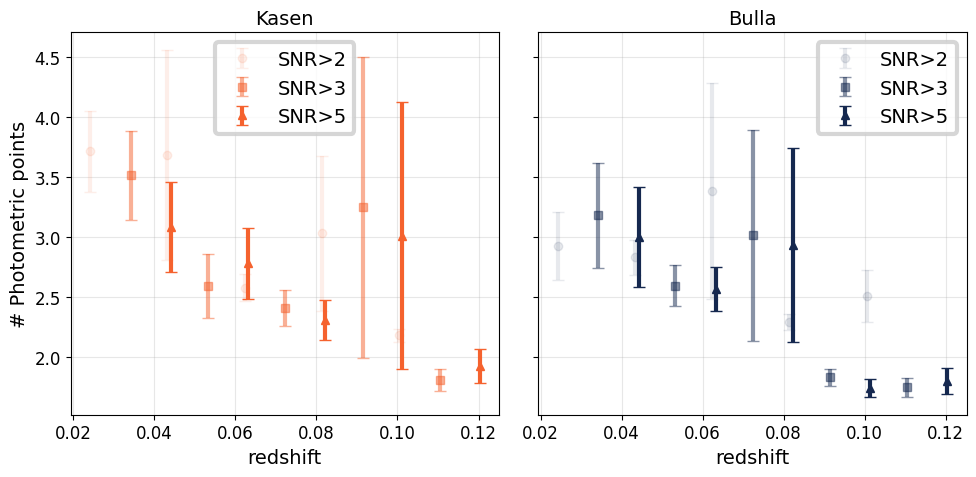

In [7]:
def plot_avg_detections_vs_redshift_models(df_phot, df_header, snr_thresholds=[3], n_bins=10, savefig=None):
    """
    Plot average number of detections per SNID vs SIM_REDSHIFT_CMB separately
    for Kasen and Bulla models with statistical error bars.
    """ 
    models = ['Kasen', 'Bulla']  # Model names
    fig, axes = plt.subplots(1, 2, figsize=(10,5), sharey=True)

    for ax, model in zip(axes, models):
        # Select SNIDs of this model
        sel_snids = df_header[df_header['model_name'] == model]['SNID']
        df_header_model = df_header[df_header['SNID'].isin(sel_snids)]
        df_phot_model = df_phot[df_phot['SNID'].isin(sel_snids)]

        for snr_threshold in snr_thresholds:
            df_sel = df_phot_model[df_phot_model['SNR'] > snr_threshold]
            detections_per_snid = df_sel.groupby('SNID').size().reset_index(name='n_detections')
            df_merged = detections_per_snid.merge(df_header_model[['SNID','SIM_REDSHIFT_CMB']], on='SNID', how='left')

            # Redshift bins
            z_min, z_max = df_merged['SIM_REDSHIFT_CMB'].min(), df_merged['SIM_REDSHIFT_CMB'].max()
            bins = np.linspace(z_min, z_max, n_bins+1)
            bin_centers = 0.5*(bins[1:] + bins[:-1])

            avg_detections = []
            std_err = []

            for i in range(n_bins):
                mask = (df_merged['SIM_REDSHIFT_CMB'] >= bins[i]) & (df_merged['SIM_REDSHIFT_CMB'] < bins[i+1])
                n_in_bin = df_merged.loc[mask, 'n_detections']
                if len(n_in_bin) > 0:
                    avg_detections.append(n_in_bin.mean())
                    std_err.append(n_in_bin.std()/np.sqrt(len(n_in_bin)))
                else:
                    avg_detections.append(np.nan)
                    std_err.append(np.nan)
            dic_alpha= {2:0.1,3:0.5,5:1.0}
            dic_markers={2:'o',3:'s',5:'^'}
            dic_offsets={2:0.0,3:0.01,5:0.02,}
            ax.errorbar(bin_centers+dic_offsets[snr_threshold], avg_detections, yerr=std_err, fmt=dic_markers[snr_threshold], capsize=4, label=f"SNR>{snr_threshold}", color=au.dic_KN_models_colors[model],alpha=dic_alpha[snr_threshold])

        ax.set_xlabel("redshift")
        ax.set_title(model)
        ax.grid(alpha=0.3)
        ax.legend()

    axes[0].set_ylabel("# Photometric points")
    plt.tight_layout()
    if savefig:
        plt.savefig(f"{path_plots}/avg_detections_vs_redshift.png")
plot_avg_detections_vs_redshift_models(df_phot, df_header, snr_thresholds=[2,3,5],savefig=True,n_bins=5)

In [8]:
for typ_str in dic_snr_3.keys():
    # Count number of rows with SNR > 5 per BAND
    snr_by_band = dic_snr_3[typ_str].groupby('BAND').size()

    # Find the BAND with the most such entries
    most_common_band = snr_by_band.idxmax()
    count_most_common_band = snr_by_band.max()
    print(f"{typ_str}: The most common BAND with SNR > 3 is {most_common_band} with {count_most_common_band} entries.")
    print(snr_by_band)
# Combine SNIDs from both models
snids_all_snr_3 = np.concatenate([
    dic_snr_3['Bulla'].SNID.values, 
    dic_snr_3['Kasen'].SNID.values
])
snids_all_snr_5 = np.concatenate([
    dic_snr_5['Bulla'].SNID.values,
    dic_snr_5['Kasen'].SNID.values
])

Kasen: The most common BAND with SNR > 3 is LSST-i with 664 entries.
BAND
LSST-Y    149
LSST-g    128
LSST-i    664
LSST-r    500
LSST-u     34
LSST-z    313
dtype: int64
Bulla: The most common BAND with SNR > 3 is LSST-i with 637 entries.
BAND
LSST-Y    275
LSST-g    143
LSST-i    637
LSST-r    455
LSST-u     34
LSST-z    418
dtype: int64


/var/folders/k7/lh2yb1wj70qfbn284kn467680000gp/T/ipykernel_97556/3274902163.py:28: RuntimeWarning: invalid value encountered in divide
  efficiency = counts_snr / counts_sim
/var/folders/k7/lh2yb1wj70qfbn284kn467680000gp/T/ipykernel_97556/3274902163.py:30: RuntimeWarning: invalid value encountered in divide
  err_efficiency = np.sqrt((err_data / counts_snr) ** 2 +
/var/folders/k7/lh2yb1wj70qfbn284kn467680000gp/T/ipykernel_97556/3274902163.py:31: RuntimeWarning: invalid value encountered in divide
  (err_sim / counts_sim) ** 2) * efficiency
/var/folders/k7/lh2yb1wj70qfbn284kn467680000gp/T/ipykernel_97556/3274902163.py:47: RuntimeWarning: invalid value encountered in divide
  efficiency = counts_snr / counts_sim
/var/folders/k7/lh2yb1wj70qfbn284kn467680000gp/T/ipykernel_97556/3274902163.py:49: RuntimeWarning: invalid value encountered in divide
  err_efficiency = np.sqrt((err_data / counts_snr) ** 2 +
/var/folders/k7/lh2yb1wj70qfbn284kn467680000gp/T/ipykernel_97556/3274902163.py:50: Runt

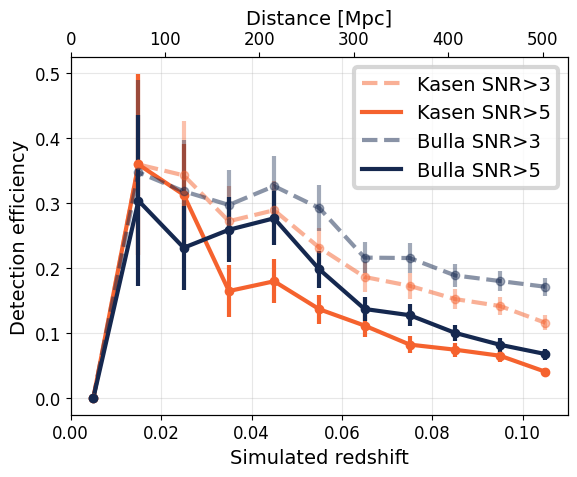

In [9]:
import matplotlib.pyplot as plt
from astropy.cosmology import Planck18 as cosmo
import numpy as np

fig = plt.figure(figsize=(6,5))
ax = plt.gca()

# Define redshift bins
bins = np.linspace(0, max(df_header['SIM_REDSHIFT_CMB']), 12)
bin_centers = 0.5 * (bins[1:] + bins[:-1])


for m, model in enumerate(df_header.model_name.unique()):
    sel = df_header[df_header.model_name == model]
    
    # All events
    counts_sim, _ = np.histogram(sel['SIM_REDSHIFT_CMB'], bins=bins)

    # Events with SNR > 3
    sel_snr = sel[sel.SNID.isin(snids_all_snr_3)]
    counts_snr, _ = np.histogram(sel_snr['SIM_REDSHIFT_CMB'], bins=bins)

    # add errors
    err_data = np.sqrt(counts_snr)
    err_sim = np.sqrt(counts_sim)
    
    # Efficiency = fraction
    efficiency = counts_snr / counts_sim
    efficiency[np.isnan(efficiency)] = 0  # Handle empty bins
    err_efficiency = np.sqrt((err_data / counts_snr) ** 2 +
                        (err_sim / counts_sim) ** 2) * efficiency
    err_efficiency = np.nan_to_num(err_efficiency)

    ax.plot(bin_centers, efficiency,  color=au.dic_KN_models_colors[model], label=f"{model} SNR>3", linestyle='dashed', alpha=0.5)
    ax.errorbar(bin_centers, efficiency, yerr=err_efficiency, color=au.dic_KN_models_colors[model],fmt='o', alpha=0.4)


    # Events with SNR > 5
    sel_snr = sel[sel.SNID.isin(snids_all_snr_5)]
    counts_snr, _ = np.histogram(sel_snr['SIM_REDSHIFT_CMB'], bins=bins)

    # add errors
    err_data = np.sqrt(counts_snr)
    err_sim = np.sqrt(counts_sim)
    
    # Efficiency = fraction
    efficiency = counts_snr / counts_sim
    efficiency[np.isnan(efficiency)] = 0  # Handle empty bins
    err_efficiency = np.sqrt((err_data / counts_snr) ** 2 +
                        (err_sim / counts_sim) ** 2) * efficiency
    err_efficiency = np.nan_to_num(err_efficiency)

    ax.plot(bin_centers, efficiency,  color=au.dic_KN_models_colors[model], label=f"{model} SNR>5")
    ax.errorbar(bin_centers, efficiency, yerr=err_efficiency, color=au.dic_KN_models_colors[model],fmt='o')

ax.set_xlabel('Simulated redshift')
ax.set_ylabel('Detection efficiency (SNR>3)')
ax.legend()
ax.grid(alpha=0.3)

plt.savefig(f'{path_plots}/efficiency_alert_vs_redshift.png')

ax.set_xlabel('Simulated redshift')
ax.set_ylabel('Detection efficiency')
ax.legend()
ax.grid(alpha=0.3)

# --- Add secondary x-axis for distance ---
def z_to_mpc(z):
    return cosmo.luminosity_distance(z).value  # in Mpc

ax2 = ax.twiny()
ax2.set_xlim(z_to_mpc(ax.get_xlim()[0]), z_to_mpc(ax.get_xlim()[1]))
ax2.set_xlabel('Distance [Mpc]')

plt.tight_layout()
plt.savefig(f'{path_plots}/efficiency_alert_vs_redshift_comparisson.png')


### Rubin Deep Drilling Fields

In [10]:
# Calculate counts
count_ddf = df_header['in_ddf_field'].sum()
total_count = len(df_header)
total_selected = len(df_header[df_header.SNID.isin(snids_all_snr_3)])

print(
    f"# Lcs in DDF fields: {count_ddf} = "
    f"{np.round(count_ddf * 100 / total_count, 2)}% of all lcs = "
    f"{np.round(count_ddf * 100 / total_selected, 2)}% of all lcs SNR>3"
)
print("DDF fields with light curves:")
for field in au.ddf_fields['Field']:
    count = df_header[df_header['ddf_field_name'] == field].shape[0]
    print(f"{field}: {count} light curves")
# Save the header and photometry dataframes to CSV files

# Lcs in DDF fields: 32 = 0.38% of all lcs = 2.0% of all lcs SNR>3
DDF fields with light curves:
ELAISS1: 4 light curves
XMM_LSS: 4 light curves
ECDFS: 11 light curves
COSMOS: 6 light curves
EDFS_a: 3 light curves
EDFS_b: 4 light curves


# Plots

In [11]:
def plot_lc_last_subplot(df_phot, df_header, idx, inmag=False, convert_date=False, savefig=False, path_plots='.'):
    """Plot only the last subplot (full Rubin LC), with dark markers for SNR>3."""

    sel_phot = df_phot[df_phot.SNID == idx].copy()
    sel_header = df_header[df_header.SNID == idx]

    if inmag:
        sel_phot = sel_phot[sel_phot["magnitude"] > 0]

    bands = sel_phot["BAND"].unique()
    x_col = "TIME" if convert_date else "MJD"
    if convert_date:
        sel_phot["TIME"] = pd.to_datetime(sel_phot["MJD"], unit="D", origin="1858-11-17")

    peakmjd = float(sel_header.PEAKMJD.values[0])
    peak_x = pd.to_datetime(peakmjd, unit="D", origin="1858-11-17") if convert_date else peakmjd

    # Y range
    if inmag:
        all_y = sel_phot["magnitude"]
        ymin, ymax = all_y.max() + 1, all_y.min() - 1
        yvar, yerr = "magnitude", "magnitude error"
    else:
        all_y = sel_phot["FLUXCAL"]
        ymin, ymax = all_y.min() - 1, all_y.max() + 1
        yvar, yerr = "FLUXCAL", "FLUXCALERR"

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(6,5))

    for flt in bands:
        sel_flt = sel_phot[sel_phot["BAND"] == flt]

        # SNR > 3 → dark
        mask_high = sel_flt['SNR'] > 3
        ax.errorbar(
            sel_flt.loc[mask_high, x_col],
            sel_flt.loc[mask_high, yvar],
            yerr=sel_flt.loc[mask_high, yerr],
            fmt="o",
            ms=6,
            alpha=0.9,
            color=au.dic_band_colors[flt],
            label=flt
        )

        # SNR ≤ 3 → faint
        mask_low = (sel_flt['SNR'] <= 3) & (sel_flt['SNR'] > 1)
        if sel_flt[mask_low].shape[0] > 0:
            ax.errorbar(
                sel_flt.loc[mask_low, x_col],
                sel_flt.loc[mask_low, yvar],
                yerr=sel_flt.loc[mask_low, yerr],
                fmt="o",
                ms=6,
                alpha=0.3,
                color=au.dic_band_colors[flt]
            )   
        # SNR ≤ 1
        mask_low = sel_flt['SNR'] < 1
        if sel_flt[mask_low].shape[0] > 0:
            ax.errorbar(
                sel_flt.loc[mask_low, x_col],
                sel_flt.loc[mask_low, yvar],
                fmt='v',
                ms=6,
                alpha=0.3,
                color=au.dic_band_colors[flt]
            )

    # Vertical line at peak
    ax.axvline(peak_x, color="black", lw=1.5, ls="--", zorder=0)

    ax.set_ylabel("magnitude" if inmag else "FLUXCAL")
    ax.set_xlabel("Date" if convert_date else "MJD", fontdict={'fontsize': 14})
    ax.set_ylim(ymin, ymax)
    ax.set_title(f"Full Rubin data\nMJD {sel_phot['MJD'].max():.1f}", fontsize=12)
    ax.tick_params(axis="x", rotation=30)
    # Legend
    ax.legend(title="Filter")

    print(f"SNID {idx} z={sel_header.REDSHIFT_FINAL.values[0]:.2f}")

    plt.tight_layout()
    if savefig:
        plt.savefig(f"{path_plots}/lc_full_{idx}_z_{sel_header.REDSHIFT_FINAL.values[0]:.2f}_{sel_header.in_ddf_field.values[0]}.png")


SNID 21504_Kasen z=0.10


ValueError: Axis limits cannot be NaN or Inf

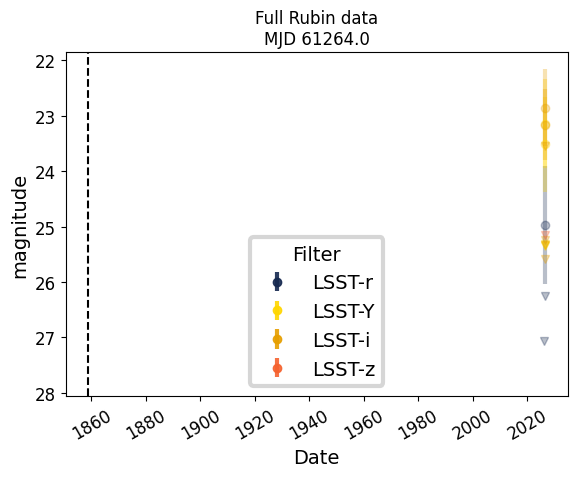

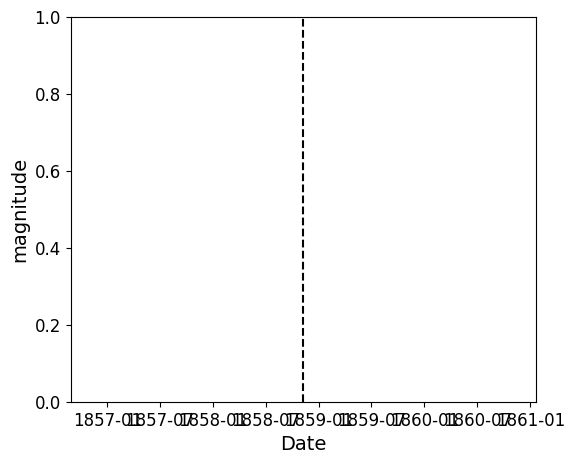

In [12]:
idxs = df_phot[df_phot['SNR'] > 1].SNID.values
for idx in list(set(idxs))[:5]:
    # plot_lc_subplots(df_phot,df_header, idx, inmag=True,convert_date=True)
    plot_lc_last_subplot(df_phot, df_header, idx, inmag=True, convert_date=True)

SNID 10803_Bulla z=0.08
SNID 20341_Bulla z=0.04
SNID 4844_Kasen z=0.07
SNID 430_Bulla z=0.09
SNID 575_Kasen z=0.07


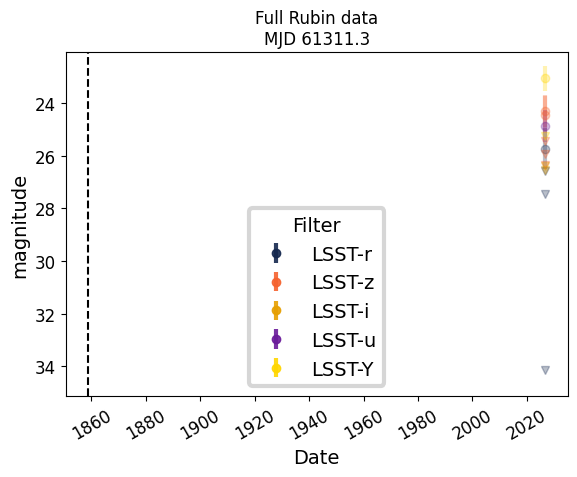

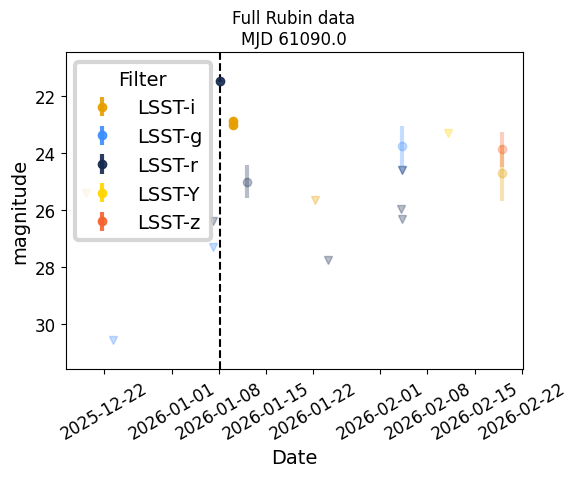

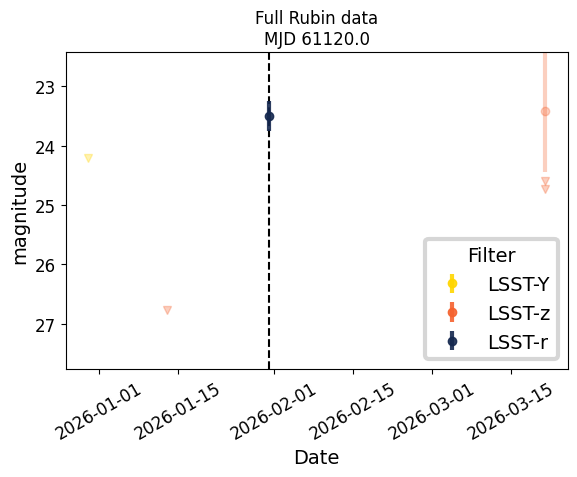

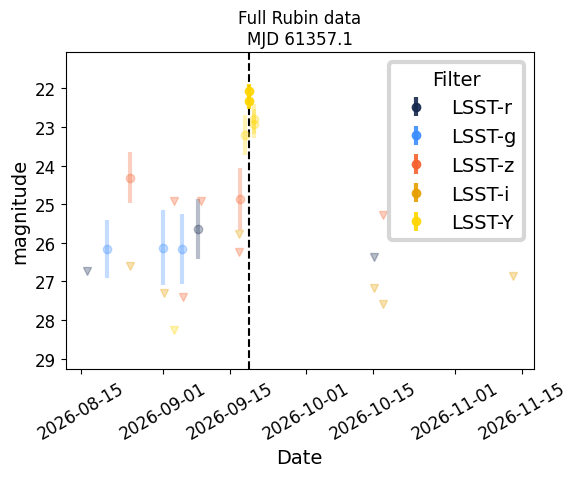

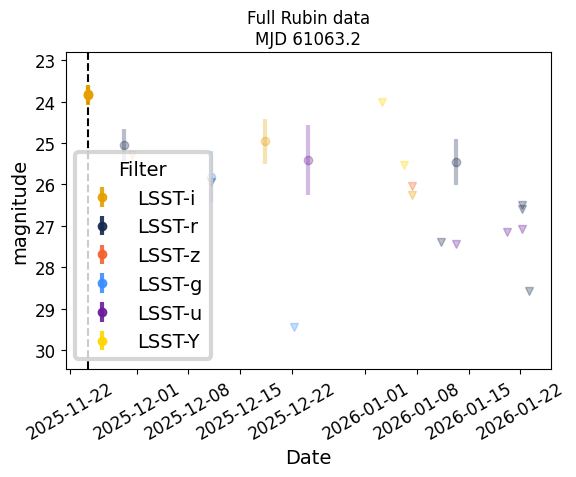

In [ ]:
for idx in list(set(snids_all_snr_3))[:5]:
    # plot_lc_subplots(df_phot,df_header, idx, inmag=True,convert_date=True)
    plot_lc_last_subplot(df_phot, df_header, idx, inmag=True, convert_date=True)


# How early are we detecting them?

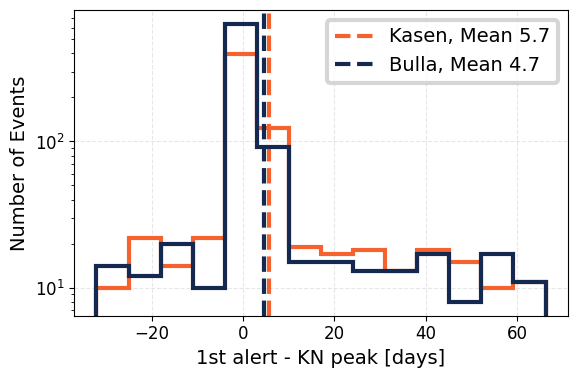

In [ ]:
# Filter to SNR > 3 detections
snr3 = df_phot[df_phot['SNR'] > 3].copy()

# Get first MJD with SNR > 3 per SNID
first_snr3 = snr3.groupby('SNID')['MJD'].min().rename('first_snr3_mjd')

# Merge with header to align with PEAKMJD
df_header_w1stsnr3 = df_header.merge(first_snr3, on='SNID', how='left')

# Compute signed difference: PEAK - first SNR > 3
df_header_w1stsnr3['delta_snr3_peak'] = np.where(
    df_header_w1stsnr3['SIM_PEAKMJD'] > 0,
    df_header_w1stsnr3['first_snr3_mjd'] - df_header_w1stsnr3['SIM_PEAKMJD'],
    np.nan
)

# Histogram bins
bins = np.linspace(df_header_w1stsnr3['delta_snr3_peak'].min(), df_header_w1stsnr3['delta_snr3_peak'].max(), 15) 

plt.figure(figsize=(6, 4))

for typ in df_header_w1stsnr3.SIM_GENTYPE.unique():
    # Filter headers for current SN type
    sel_header = df_header_w1stsnr3[(df_header_w1stsnr3.SIM_GENTYPE == typ)].copy()
    
    # Drop NaNs
    data_snr3 = sel_header['delta_snr3_peak'].dropna()
    
    # Choose color per type
    color = au.dic_KN_models_colors[au.dic_sntype[str(typ)]]
    
    # Step histogram
    plt.hist(data_snr3, bins=bins, histtype='step', color=color)
    
    # Mean line
    mean_snr3 = data_snr3.mean()
    plt.axvline(mean_snr3, color=color, linestyle='dashed',
                label=f'{au.dic_sntype[str(typ)]}, Mean {mean_snr3:.1f}')
    
plt.xlabel('1st alert - KN peak [days]')
plt.ylabel('Number of Events')
plt.yscale('log')
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(f'{path_plots}/first_alert_vs_peak.png')

Kasen 0.0004000000008090865 7.683491758102299
Kasen 0.042699999998148996 8.621706631407898
Bulla 0.0003999999971711077 8.138117921651123
Bulla 1.1031999999977415 28.050429400100917


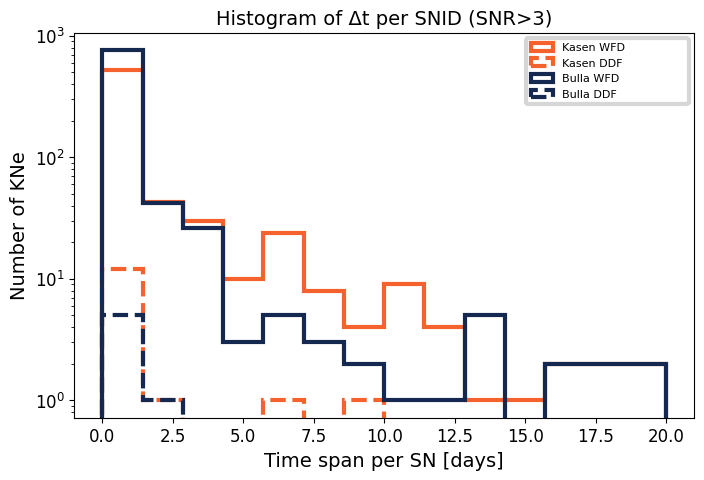

In [ ]:
plt.figure(figsize=(8,5))
mybins = np.linspace(0, 20, 15)  # Adjust bins as needed

for mod in snr3['model_name'].unique():
    for f in snr3['FIELD'].unique():
        sel = snr3[(snr3['model_name'] == mod) & (snr3['FIELD'] == f)]
        if len(sel) == 0:
            continue
        
        # compute delta_times for this group only
        delta_times_group = sel.groupby("SNID")["MJD"].agg(lambda x: x.max() - x.min())
        
        # handle bytes or str
        f_str = f.decode() if isinstance(f, bytes) else f
        linestyle = '-' if 'WFD' in f_str else '--'
        plt.hist(delta_times_group, bins=mybins, histtype='step', color=au.dic_KN_models_colors.get(mod, 'k') , linestyle=linestyle, label=f"{mod} {f_str}")
        median_val = delta_times_group.median()
        print(mod,median_val,std_val := delta_times_group.std())

plt.xlabel("Time span per SN [days]")
plt.ylabel("Number of KNe")
plt.yscale("log")
plt.title("Histogram of Δt per SNID (SNR>3)")
plt.legend(fontsize=8)
plt.show()


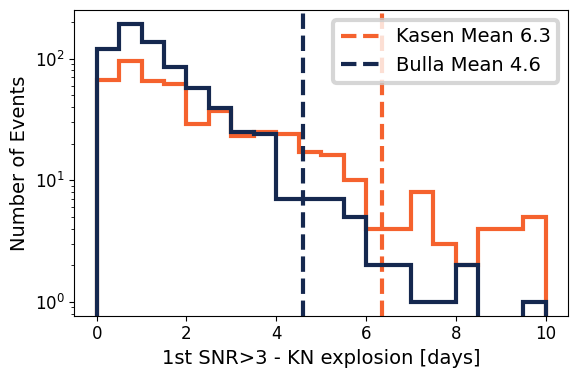

In [ ]:
   
plt.figure(figsize=(6, 4))
bins = np.linspace(0, 10, 21)  # 10 bins between 0 and 10

for typ in df_header.SIM_GENTYPE.unique():
    sel_header = df_header_w1stsnr3[df_header_w1stsnr3.SIM_GENTYPE == typ].copy()
    sel = df_phot[df_phot.SNID.isin(sel_header.SNID)]
    
    # Compute delta between peak and explosion
    sel_header['delta_firstsnr3_explode'] = sel_header['first_snr3_mjd'] - sel_header['SIM_MJD_EXPLODE']

    # Choose color per type
    color = au.dic_KN_models_colors[au.dic_sntype[str(typ)]]
    
    # All events (dashed step)
    # plt.hist(data_all, bins=bins, histtype='step', linestyle='dashed', color=color,linewidth=1.5)
    
    # SNR>5 events (solid step)
    plt.hist(sel_header['delta_firstsnr3_explode'], bins=bins, histtype='step', color=color)

    mean_snr = sel_header['delta_firstsnr3_explode'].mean()
    plt.axvline(mean_snr, color=color, linestyle='dashed', 
                label=f'{au.dic_sntype[str(typ)]} Mean {mean_snr:.1f}')

plt.xlabel('1st SNR>3 - KN explosion [days]')
plt.ylabel('Number of Events')
plt.legend()
plt.yscale('log')
plt.tight_layout()
plt.savefig(f'{path_plots}/first_snr3_vs_explosion.png')
plt.show()
